---
title: ML on Graphs - PyTorch Geometric Tutorial
date: "November 2023"
date-format: MMMM YYYY
format:
    html:
      html-math-method: katex
      toc: true
      grid:
        margin-width: 320px
      code-fold: true
reference-location: margin
citation-location: document #margin
bibliography: references.bib
csl: ieee.csl
---

In this tutorial, I will cover some basic Graph Neural Networks algorithms on benchmark datasets. You can either read and review the code snippets here or directly go to the entire notebooks in Github project.


## 1. Graph Neural Networks Background

Convolutional neural networks (or, more broadly, deep learning) work well on various data domains including image classification, speech recognition, and natural language processing. Most of these data domains have structured grids where we can assume local connectivity between data points. However, many data modalities lie in non-Euclidean spaces, from social graphs to gene expression or neuroscience. 

For a more detailed review, please see these comprehensive reviews: [@Bronstein:2017],[@Wu:2021]. In this post, I will focus on one of the initial examples, Kipf and Welling's ICLR 2017 paper: [Semi-Supervised Classification with Graph Convolutional Networks](https://openreview.net/forum?id=SJU4ayYgl) [@Kipf:2017].

### Semi-Supervised Classification with Graph Convolutional Networks
The problem considered in the main paper is the classification of nodes in a graph. It differs from the usual classification problems we had in the image or video domain. Instead of having small instances, we have a huge graph with nodes (i.e., documents) and edges between them (citation), and the task is to classify each node. For instance, classifying each paper's topic can be an example of node classification.

$$
\mathcal{L}=\mathcal{L}_0 + \lambda \mathcal{L}_{reg} \qquad \mathcal{L}_{reg}=\sum_{i,j} A_{i,j} \lVert f(X_i)-f(X_j) \rVert^2=f(x)^T\Delta f(x)
$$ {#eq-1}

We can think of the problem as having a big citation graph, but only a part of the papers in the graph are labeled; for instance, their topics are known. The task is to learn to predict unlabeled nodes' topics. $\mathcal{L}_0$ is a supervised loss learned w.r.t. the labeled part of the graph. $f(.)$ can be a differentiable function, $\lambda$ is weighting factor, and $X$ is a matrix of node feature vectors, $X_i$. 

$\Delta=D-A$ denotes the unnormalized graph Laplacian of an undirected graph $\mathcal{G}=(\mathcal{V},\mathcal{E})$ with nodes $v_i \in \mathcal{V}$, edges $(v_i,v_j) \in \mathcal{E}$.

* Degree matrix, $D$ where $D_{ii}=\sum_{j} A_{ij}$ (If there is a self-loop, it contributes 2 to the vertex's degree.)
* Adjacency matrix, $A$, a binary or weighted square matrix containing the information of whether the pairs of indices are adjacent or not.

This paper proposes the following propagation rule of spectral graph convolutions:
$$
H^{l+1}  = \sigma \Big( \widetilde{D}^{\frac{1}{2}} \widetilde{A} \widetilde{D}^{\frac{1}{2}} H^{(l)} W^{(l)} \Big)
$$ {#eq-2}

* $\widetilde{A}=A+I_N$: adjaceny matrix of undirected graph $\mathcal{G}$ with added self-connections.
* $I_N$: the identity matrix
* $\widetilde{D}_{ii}=\sum_j{\widetilde{A}_{ij}}$, layer specific trainable weight matrix
* $\sigma$, activation function such as $ReLU(.)=max(0,.)$
* $H^{(l)} \in \mathbb{R}^{N \times D}$ is the matrix activations in the $l^{th}$ layer; $H^{(l)}=X$



## 2. Toy Example: KarateClub

Zachary’s karate club network [@Zachary:1977]: this graph contains 34 nodes, connected by 154 (undirected and unweighted) edges. Every node is labeled by one of four classes, obtained via modularity-based clustering [@Brandes:2007].

Karate Club is already included in PyG's standard datasets. We first load it and check the the number of features and classes:

In [4]:
import numpy as np
import torch
import torch_geometric
from torch_geometric.data import Data
from torch_geometric.utils import to_networkx
import networkx as nx

import matplotlib.pyplot as plt
plt.style.use('ggplot')

dataset = torch_geometric.datasets.KarateClub()
print('Dataset: KarateClub')
print(' - the number of graphs =', len(dataset))
print(' - the number of features =', dataset.num_features)
print(' - the number of classes =', dataset.num_classes)

Dataset: KarateClub
 - the number of graphs = 1
 - the number of features = 34
 - the number of classes = 4


Now, using `NetworkX` library, we visualize the entire graph by coloring the nodes of each label seperately:

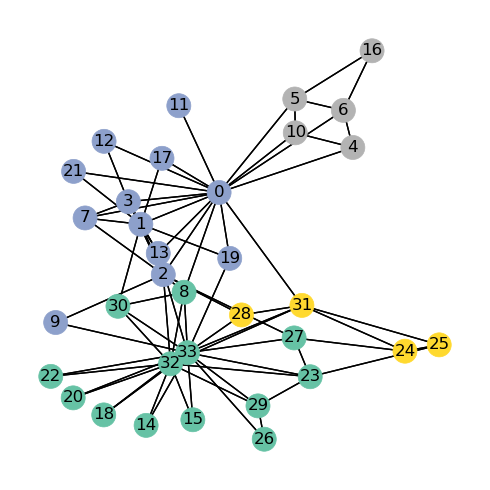

In [5]:
G = to_networkx(dataset[0])
plt.figure(figsize=(5,5))
nx.draw_networkx(G, pos=nx.spring_layout(G, seed=42), arrows=False,
                 node_color=dataset[0].y, cmap="Set2")

plt.tight_layout()
plt.axis("off")
plt.show()

#### Implementing Graph Neural Networks

```python
class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        torch.manual_seed(1234)
        self.conv1 = torch_geometric.nn.GCNConv(dataset.num_features, 4)
        self.conv2 = torch_geometric.nn.GCNConv(4, 4)
        self.conv3 = torch_geometric.nn.GCNConv(4, 2)
        self.classifier = torch.nn.Linear(2, dataset.num_classes)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index)
        h = h.tanh()
        h = self.conv2(h, edge_index)
        h = h.tanh()
        h = self.conv3(h, edge_index)
        h = h.tanh()  # Final GNN embedding space.
        
        # Apply a final (linear) classifier.
        out = self.classifier(h)

        return out, h

```

In [8]:
#| eval: true
#| echo: false

class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        torch.manual_seed(1234)
        self.conv1 = torch_geometric.nn.GCNConv(dataset.num_features, 4)
        self.conv2 = torch_geometric.nn.GCNConv(4, 4)
        self.conv3 = torch_geometric.nn.GCNConv(4, 2)
        self.classifier = torch.nn.Linear(2, dataset.num_classes)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index)
        h = h.tanh()
        h = self.conv2(h, edge_index)
        h = h.tanh()
        h = self.conv3(h, edge_index)
        h = h.tanh()  # Final GNN embedding space.
        
        # Apply a final (linear) classifier.
        out = self.classifier(h)
        return out, h

In [9]:
#| eval: true
#| echo: false

model = GCN()
print(model)

GCN(
  (conv1): GCNConv(34, 4)
  (conv2): GCNConv(4, 4)
  (conv3): GCNConv(4, 2)
  (classifier): Linear(in_features=2, out_features=4, bias=True)
)


#### Embedding the Karate Club Network

Now we apply only a forward pass and get the embeddings in the output of 3th GCN layer in size of 2 and see scatter plot:

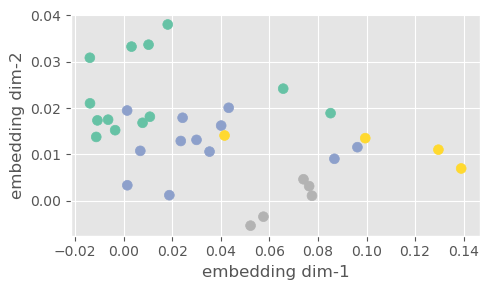

In [31]:
model = GCN()

data = dataset[0]  # get the first graph object.
_, h = model(data.x, data.edge_index)
h = h.cpu().detach().numpy()

plt.figure(figsize=(5,3))
plt.scatter(h[:, 0], h[:, 1], s=50, c=data.y, cmap="Set2")
plt.xlabel('embedding dim-1')
plt.ylabel('embedding dim-2')
plt.tight_layout()
plt.show()

#### Training of the Karate Club Network

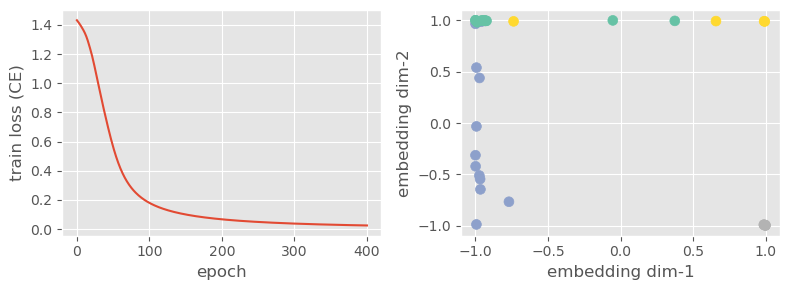

In [48]:
model = GCN()
criterion = torch.nn.CrossEntropyLoss()  # Define loss criterion.
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # Define optimizer.

def train(data):
    optimizer.zero_grad()  # Clear gradients.
    out, h = model(data.x, data.edge_index)  # Perform a single forward pass.
    loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Compute the loss solely based on the training nodes.
    loss.backward()  # Derive gradients.
    optimizer.step()  # Update parameters based on gradients.
    return loss, h

train_epoch, train_loss = [], []
for epoch in range(401):
    loss, h = train(data)
    train_epoch.append(epoch)
    train_loss.append(loss.item())

fig, ax = plt.subplots(1, 2, figsize=(8,3))
ax[0].plot(train_epoch, train_loss)
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('train loss (CE)')
h = h.cpu().detach().numpy()
ax[1].scatter(h[:, 0], h[:, 1], s=50, c=data.y, cmap="Set2")
ax[1].set_xlabel('embedding dim-1')
ax[1].set_ylabel('embedding dim-2')
plt.tight_layout()
plt.show()

## 3. Reproducing Experiments in the Paper

Now let's try to reproduce the experiments in the paper

In [109]:
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures

dataset = Planetoid(root='./datasets', name='Cora', transform=NormalizeFeatures())

print()
print(f'Dataset: {dataset}:')
print('======================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

data = dataset[0]  # Get the first graph object.
print()
print(data)
print('======================')
# Gather some statistics about the graph.
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Number of training nodes: {data.train_mask.sum()}')
print(f'Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')


Dataset: Cora():
Number of graphs: 1
Number of features: 1433
Number of classes: 7

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
Number of nodes: 2708
Number of edges: 10556
Average node degree: 3.90
Number of training nodes: 140
Training node label rate: 0.05
Has isolated nodes: False
Has self-loops: False
Is undirected: True


In [52]:
import torch
from torch.nn import Linear
import torch.nn.functional as F


class MLP(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        torch.manual_seed(12345)
        self.lin1 = Linear(dataset.num_features, hidden_channels)
        self.lin2 = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x):
        x = self.lin1(x)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin2(x)
        return x

model = MLP(hidden_channels=16)
print(model)

MLP(
  (lin1): Linear(in_features=1433, out_features=16, bias=True)
  (lin2): Linear(in_features=16, out_features=7, bias=True)
)


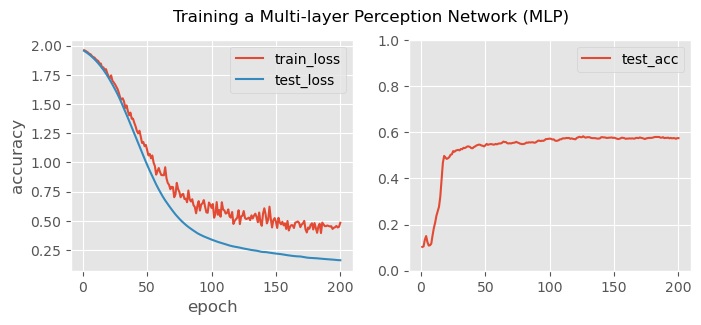

In [78]:
model = MLP(hidden_channels=16)
criterion = torch.nn.CrossEntropyLoss()  # Define loss criterion.
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)  # Define optimizer.

def train():
    model.train()
    optimizer.zero_grad()  # Clear gradients.
    out = model(data.x)  # Perform a single forward pass.
    loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Compute the loss solely based on the training nodes.
    loss.backward()  # Derive gradients.
    optimizer.step()  # Update parameters based on gradients.
    return loss.item()

def test():
    model.eval()
    out = model(data.x)
    loss = criterion(out[data.train_mask], data.y[data.train_mask]) 
    pred = out.argmax(dim=1)  # Use the class with highest probability.
    test_correct = pred[data.test_mask] == data.y[data.test_mask]  # Check against ground-truth labels.
    test_acc = int(test_correct.sum()) / int(data.test_mask.sum())  # Derive ratio of correct predictions.
    return loss.item(), test_acc


logs = []
for epoch in range(1, 201):

    # train
    train_loss = train()
    # test
    test_loss, test_acc = test()

    logs.append([epoch, train_loss, test_loss, test_acc])
logs = np.array(logs)

fig, ax = plt.subplots(1, 2, figsize=(8,3))
fig.suptitle('Training a Multi-layer Perception Network (MLP)')
ax[0].plot(logs[:,0], logs[:,1], label='train_loss')
ax[0].plot(logs[:,0], logs[:,2], label='test_loss')
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('loss')
ax[0].legend(loc="upper right")
ax[1].plot(logs[:,0], logs[:,3], label='test_acc')
ax[1].set_ylim([0, 1.0])
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('accuracy')
ax[1].legend(loc="upper right")
plt.show()

# extract all embeddings
model.eval()
MLP_embeddings = model(data.x)

In [79]:
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        torch.manual_seed(1234567)
        self.conv1 = GCNConv(dataset.num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

model = GCN(hidden_channels=16)
print(model)

GCN(
  (conv1): GCNConv(1433, 16)
  (conv2): GCNConv(16, 7)
)


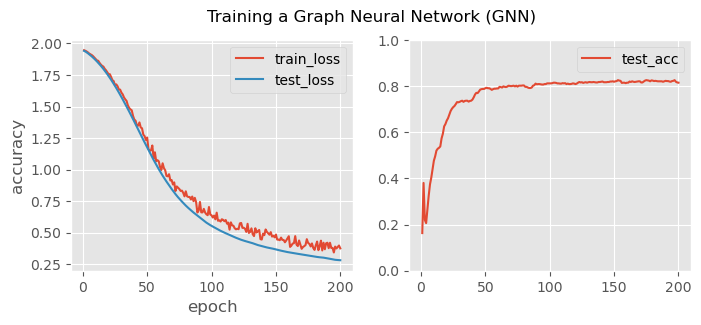

In [80]:
criterion = torch.nn.CrossEntropyLoss()  # Define loss criterion.
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)  # Define optimizer.

def train():
    model.train()
    optimizer.zero_grad()  # Clear gradients.
    out = model(data.x, data.edge_index)  # Perform a single forward pass.
    loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Compute the loss solely based on the training nodes.
    loss.backward()  # Derive gradients.
    optimizer.step()  # Update parameters based on gradients.
    return loss.item()

def test():
    model.eval()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask]) 
    pred = out.argmax(dim=1)  # Use the class with highest probability.
    test_correct = pred[data.test_mask] == data.y[data.test_mask]  # Check against ground-truth labels.
    test_acc = int(test_correct.sum()) / int(data.test_mask.sum())  # Derive ratio of correct predictions.
    return loss.item(), test_acc


logs = []
for epoch in range(1, 201):

    # train
    train_loss = train()
    # test
    test_loss, test_acc = test()

    logs.append([epoch, train_loss, test_loss, test_acc])
logs = np.array(logs)

fig, ax = plt.subplots(1, 2, figsize=(8,3))
fig.suptitle('Training a Graph Neural Network (GNN)')
ax[0].plot(logs[:,0], logs[:,1], label='train_loss')
ax[0].plot(logs[:,0], logs[:,2], label='test_loss')
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('loss')
ax[0].legend(loc="upper right")
ax[1].plot(logs[:,0], logs[:,3], label='test_acc')
ax[1].set_ylim([0, 1.0])
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('accuracy')
ax[1].legend(loc="upper right")
plt.show()

# extract all embeddings
model.eval()
GCN_embeddings = model(data.x, data.edge_index)

In [84]:
MLP_embeddings = MLP_embeddings.cpu().detach().numpy()
GCN_embeddings = GCN_embeddings.cpu().detach().numpy()

In [88]:
from sklearn.manifold import TSNE

z_MLP = TSNE(n_components=2).fit_transform(MLP_embeddings)
z_GCN = TSNE(n_components=2).fit_transform(GCN_embeddings)

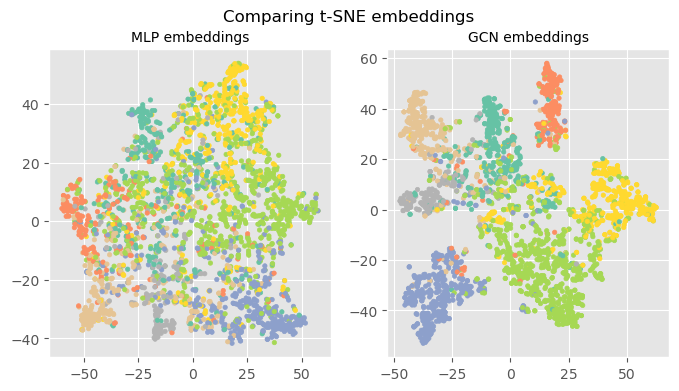

In [107]:
fig, ax = plt.subplots(1, 2, figsize=(8,4))
fig.suptitle('Comparing t-SNE embeddings', fontsize=12)
ax[0].scatter(z_MLP[:,0], z_MLP[:,1], s=10,  c=data.y.numpy(), cmap="Set2")
ax[0].set_title('MLP embeddings', fontsize=10)

ax[1].scatter(z_GCN[:,0], z_GCN[:,1], s=10, c=data.y.numpy(), cmap="Set2")
ax[1].set_title('GCN embeddings', fontsize=10)
plt.show()